# Лабораторная работа 1: UpSet plot пропусков

**Данные:** [Beijing Multi-Site Air Quality, UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/501/beijing%2Bmulti%2Bsite%2Bair%2B%20quality%2Bdata). В локальном архиве `beijing_air_quality_uci.zip` находятся исходные CSV для 12 станций. Набор содержит 420 768 часовых наблюдений и 18 исходных столбцов. Пропущенные измерения в CSV обозначены `NA`.

**Цель:** показать точные сочетания пропусков по измеряемым полям и посмотреть, как станции и сезоны распределены внутри этих сочетаний. График сохраняет прежнюю структуру: столбики пересечений, матрицу пропусков, размеры множеств слева и нижнюю таблицу долей признаков.


In [6]:
from collections import Counter, defaultdict
import csv
import io
from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

DATA_PATH = Path("beijing_air_quality_uci.zip")
assert DATA_PATH.is_file(), f"Не найден {DATA_PATH.resolve()}"

# Дата, время и название станции не входят в множества пропусков.
sets = [
    "PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
    "TEMP", "PRES", "DEWP", "RAIN", "wd", "WSPM",
]
MAX_PATTERNS = 25

def is_nan(value):
    return value is None or value.strip() == "" or value.strip().upper() == "NA"

def season_of(month):
    if month in (12, 1, 2):
        return "Зима"
    if month in (3, 4, 5):
        return "Весна"
    if month in (6, 7, 8):
        return "Лето"
    return "Осень"


## 1. Чтение данных и подсчёт пропусков

Читаем CSV из архива по одному: весь набор не нужно распаковывать или держать в памяти. Каждой записи соответствует логическая маска из 12 значений: `True`, если в измеряемом поле стоит `NA`. Для нижней панели одновременно считаем станцию и сезон записи. Исходные данные не меняются.


In [7]:
pattern_counts = Counter()
missing_counts = Counter()
feature_totals = Counter()
features_by_pattern = defaultdict(Counter)
station_names = set()
row_count = 0

with ZipFile(DATA_PATH) as archive:
    members = sorted(name for name in archive.namelist() if name.endswith(".csv"))
    assert len(members) == 12, f"Ожидалось 12 файлов станций, найдено {len(members)}"
    for member in members:
        with archive.open(member) as raw:
            reader = csv.DictReader(io.TextIOWrapper(raw, encoding="utf-8"))
            assert set(sets).issubset(reader.fieldnames), member
            for row in reader:
                row_count += 1
                mask = tuple(is_nan(row[name]) for name in sets)
                pattern_counts[mask] += 1
                missing_counts.update(name for name, flag in zip(sets, mask) if flag)

                station = row["station"]
                season = season_of(int(row["month"]))
                station_names.add(station)
                feature_totals[station] += 1
                feature_totals[season] += 1
                features_by_pattern[mask][station] += 1
                features_by_pattern[mask][season] += 1

assert row_count == 420768
print(f"Записей: {row_count:,}; станций: {len(station_names)}")
print("Столбцы с пропусками:")
for name in sets:
    print(f"  {name}: {missing_counts[name]:,}")


Записей: 420,768; станций: 12
Столбцы с пропусками:
  PM2.5: 8,739
  PM10: 6,449
  SO2: 9,021
  NO2: 12,116
  CO: 20,701
  O3: 13,277
  TEMP: 398
  PRES: 393
  DEWP: 403
  RAIN: 390
  wd: 1,822
  WSPM: 318


## 2. Точные сочетания пропусков

Сочетание означает, что отсутствуют **ровно** указанные поля, а остальные измеряемые поля заполнены. Строки без пропусков не входят в UpSet-множества и показываются отдельно. В графике ниже показаны 25 самых частых сочетаний из всех найденных; они отсортированы по числу записей.


In [8]:
complete_mask = tuple(False for _ in sets)
complete_count = pattern_counts.pop(complete_mask, 0)
all_intersections = pattern_counts.most_common()
intersections = all_intersections[:MAX_PATTERNS]
with_missing = sum(pattern_counts.values())
shown = sum(count for _, count in intersections)

print(f"Без пропусков: {complete_count:,}")
print(f"С пропусками: {with_missing:,}")
print(f"Точных сочетаний: {len(all_intersections)}")
print(f"На графике: {len(intersections)} сочетаний, {shown:,} записей "
      f"({shown / with_missing:.1%} записей с пропусками)")
for i, (mask, count) in enumerate(intersections[:10], 1):
    print(f"№{i:02d}: {count:,} — " + ", ".join(name for name, flag in zip(sets, mask) if flag))


Без пропусков: 382,168
С пропусками: 38,600
Точных сочетаний: 81
На графике: 25 сочетаний, 38,083 записей (98.7% записей с пропусками)
№01: 11,298 — CO
№02: 5,276 — NO2
№03: 5,015 — O3
№04: 4,951 — PM2.5, PM10, SO2, NO2, CO, O3
№05: 2,124 — PM2.5
№06: 1,884 — SO2
№07: 1,867 — CO, O3
№08: 1,417 — wd
№09: 904 — SO2, CO
№10: 818 — PM2.5, PM10


## 3. UpSet plot и доли признаков

Верхние узкие цветные столбики — число записей в точном сочетании. Матрица под ними отмечает отсутствующие поля цветными точками; слева показано число пропусков в каждом поле.

**Нижняя таблица сохранена:** каждая ячейка показывает долю выбранной станции или сезона **внутри конкретного сочетания**. Горизонтальные оранжевые столбики слева от таблицы показывают численность станции или сезона во всём наборе. Станции и сезоны — дополнительные признаки для сравнения, а не новые множества NaN.


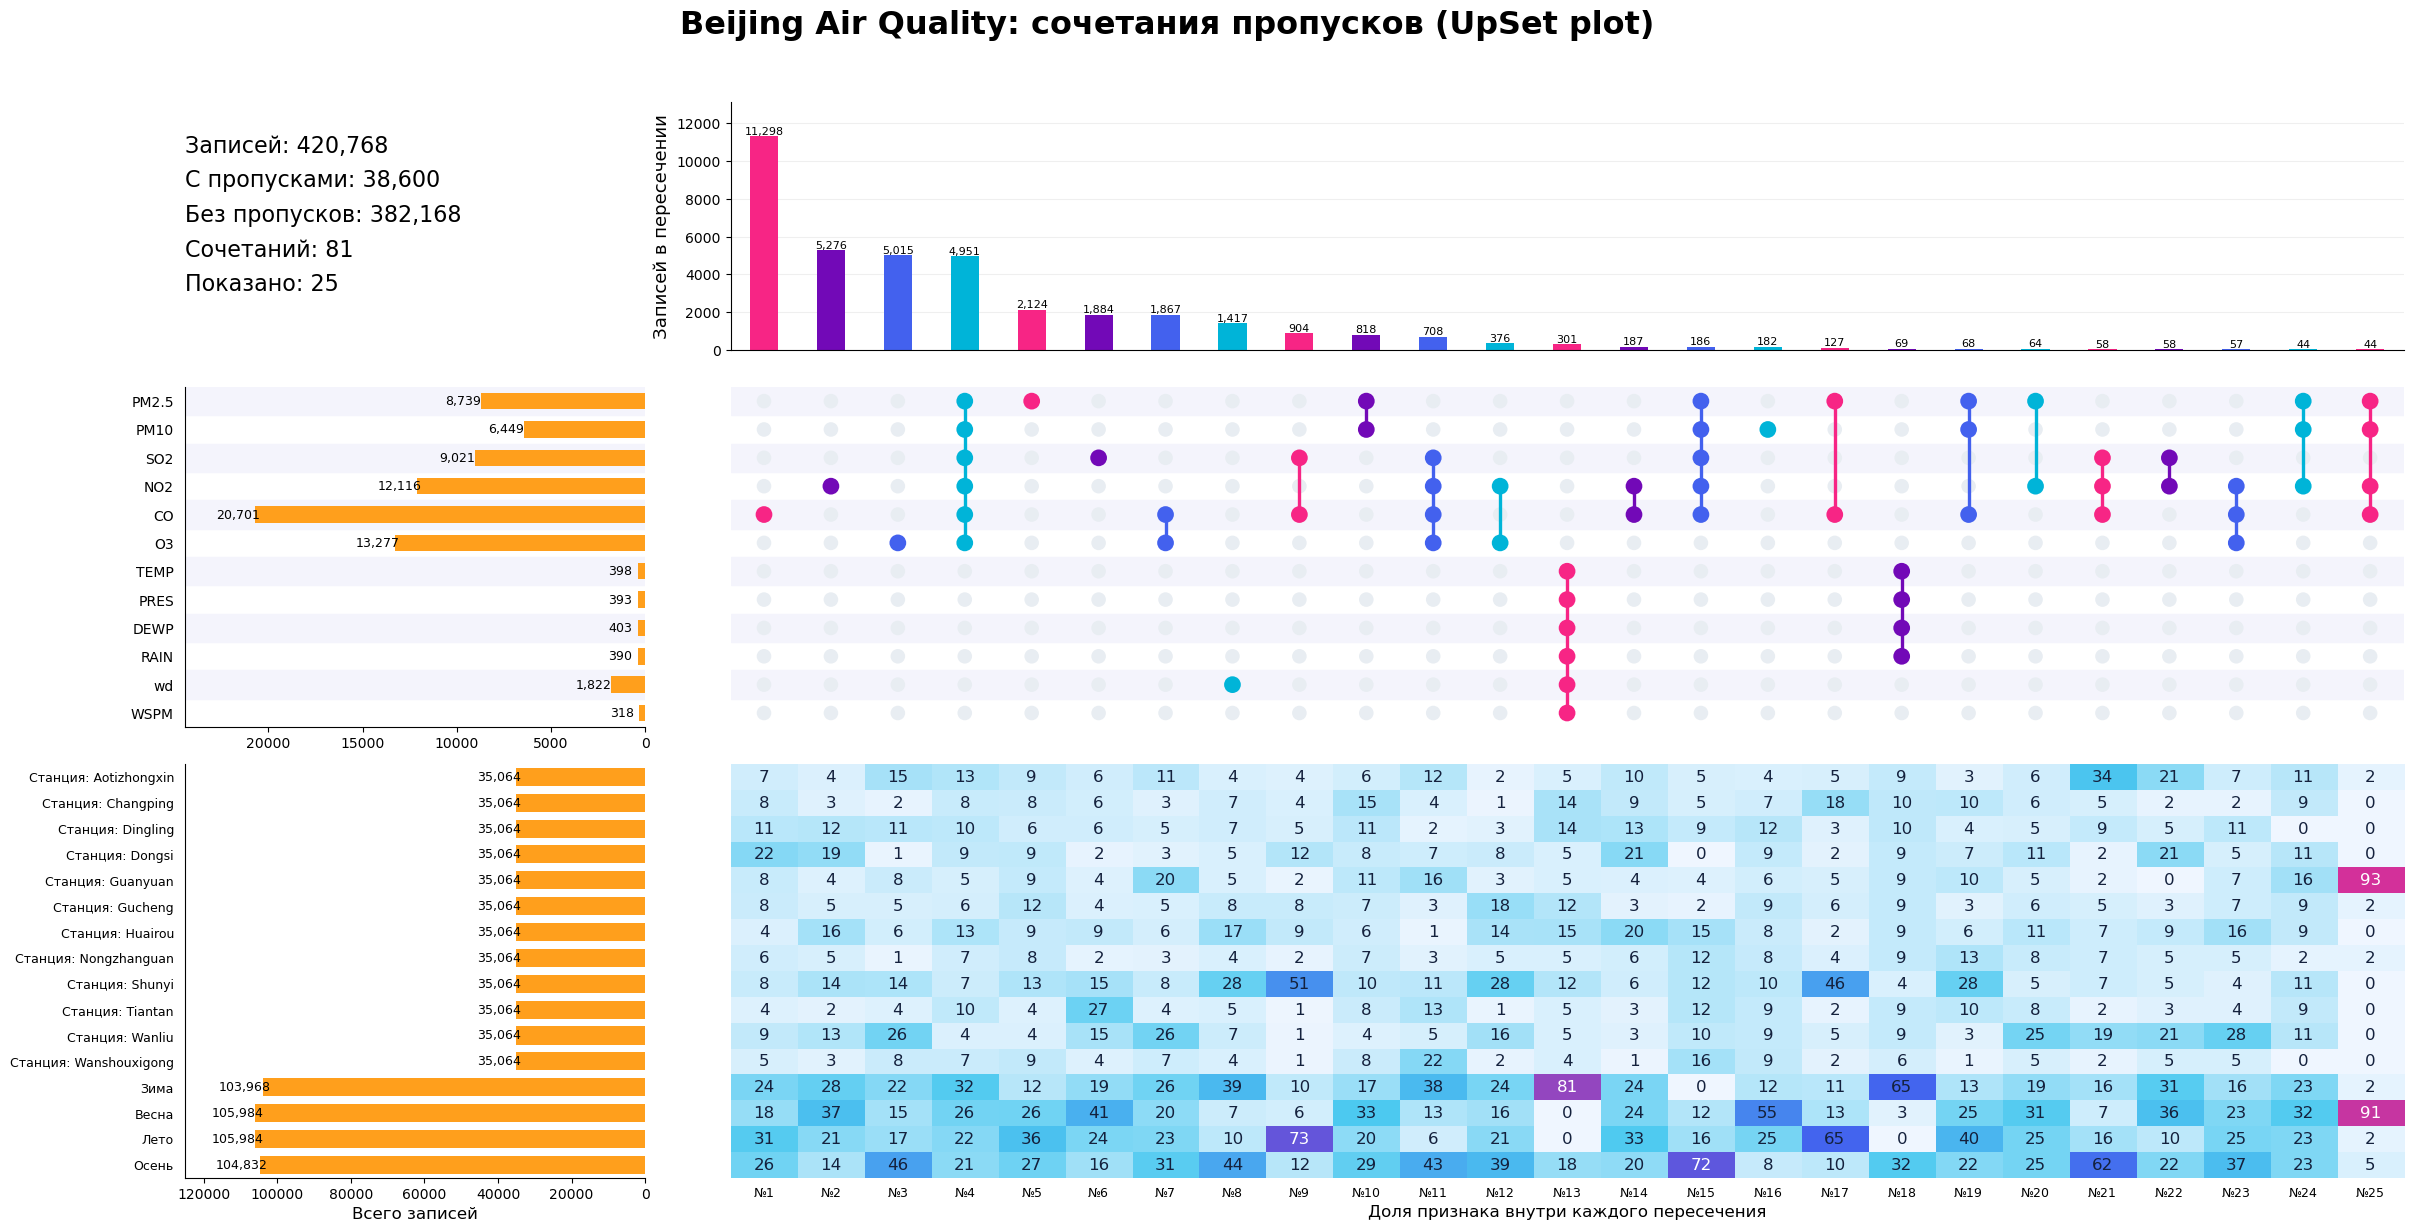

In [9]:
plt.rcParams["font.family"] = "DejaVu Sans"

patterns = [mask for mask, _ in intersections]
heights = [count for _, count in intersections]
xs = list(range(len(patterns)))
ys = list(range(len(sets)))
feature_labels = [f"Станция: {name}" for name in sorted(station_names)]
feature_labels += ["Зима", "Весна", "Лето", "Осень"]
feature_keys = sorted(station_names) + ["Зима", "Весна", "Лето", "Осень"]
feature_sizes = [feature_totals[key] for key in feature_keys]
feature_shares = [
    [features_by_pattern[mask][key] / count for mask, count in intersections]
    for key in feature_keys
]

fig = plt.figure(figsize=(25.5, 13.2))
grid = GridSpec(
    3, 2, figure=fig, width_ratios=[2.2, 8], height_ratios=[2.7, 3.7, 4.5],
    left=0.115, right=0.985, top=0.89, bottom=0.075, wspace=0.08, hspace=0.11,
)
ax_info = fig.add_subplot(grid[0, 0])
ax_bars = fig.add_subplot(grid[0, 1])
ax_sets = fig.add_subplot(grid[1, 0])
ax_matrix = fig.add_subplot(grid[1, 1], sharex=ax_bars)
ax_totals = fig.add_subplot(grid[2, 0])
ax_features = fig.add_subplot(grid[2, 1], sharex=ax_bars)

ax_info.axis("off")
ax_info.text(
    0, 0.87,
    f"Записей: {row_count:,}\n"
    f"С пропусками: {with_missing:,}\n"
    f"Без пропусков: {complete_count:,}\n"
    f"Сочетаний: {len(all_intersections)}\n"
    f"Показано: {len(intersections)}",
    fontsize=16, va="top", linespacing=1.65,
)

colors = ["#F72585", "#7209B7", "#4361EE", "#00B4D8"]
bar_colors = [colors[x % len(colors)] for x in xs]
ax_bars.bar(xs, heights, color=bar_colors, width=0.42)
for x, count in zip(xs, heights):
    ax_bars.text(x, count, f"{count:,}", ha="center", va="bottom", fontsize=8)
ax_bars.set_ylabel("Записей в пересечении", fontsize=13)
ax_bars.set_ylim(0, max(heights) * 1.16)
ax_bars.spines[["top", "right"]].set_visible(False)
ax_bars.grid(axis="y", alpha=0.2)
ax_bars.set_axisbelow(True)

max_set = max(missing_counts.values())
for y in ys:
    if y % 2 == 0:
        for ax in (ax_sets, ax_matrix):
            ax.axhspan(y - 0.5, y + 0.5, color="#f4f4fc", zorder=0)
ax_sets.barh(ys, [missing_counts[name] for name in sets],
             color="#FF9F1C", height=0.58)
for y, name in enumerate(sets):
    ax_sets.text(missing_counts[name] + max_set * 0.045, y,
                 f"{missing_counts[name]:,}", ha="center", va="center", fontsize=9)
ax_sets.set_yticks(ys, labels=sets)
ax_sets.set_xlim(max_set * 1.18, 0)
ax_sets.set_ylim(len(sets) - 0.5, -0.5)
ax_sets.tick_params(axis="y", length=0, pad=8, labelsize=10)
ax_sets.spines[["top", "right"]].set_visible(False)

# Сначала фоновые точки, затем линии, затем цветные точки. Так светлые
# маркеры не перекрывают цветные соединения между выбранными полями.
for x in xs:
    ax_matrix.scatter([x] * len(ys), ys, s=110, zorder=1,
                      facecolor="#e8edf2", edgecolor="none")
for x, mask in enumerate(patterns):
    selected = [y for y, flag in enumerate(mask) if flag]
    if len(selected) > 1:
        ax_matrix.plot([x, x], [min(selected), max(selected)],
                       color=bar_colors[x], linewidth=2.4, zorder=2)
    ax_matrix.scatter([x] * len(selected), selected, s=145, zorder=3,
                      facecolor=bar_colors[x], edgecolor="none")
ax_matrix.set_xlim(-0.5, len(xs) - 0.5)
ax_matrix.set_ylim(len(sets) - 0.5, -0.5)
ax_matrix.set_yticks([])
ax_matrix.spines[:].set_visible(False)

feature_ys = list(range(len(feature_keys)))
max_feature = max(feature_sizes)
ax_totals.barh(feature_ys, feature_sizes, color="#FF9F1C", height=0.7)
for y, count in enumerate(feature_sizes):
    ax_totals.text(count + max_feature * 0.045, y, f"{count:,}",
                   ha="center", va="center", fontsize=9)
ax_totals.set_yticks(feature_ys, labels=feature_labels)
ax_totals.set_ylim(len(feature_ys) - 0.5, -0.5)
ax_totals.set_xlim(max_feature * 1.18, 0)
ax_totals.set_xlabel("Всего записей", fontsize=12)
ax_totals.tick_params(axis="y", length=0, pad=8, labelsize=9)
ax_totals.spines[["top", "right"]].set_visible(False)

palette = LinearSegmentedColormap.from_list(
    "bright_shares", ["#eff6ff", "#4CC9F0", "#4361EE", "#F72585"]
)
ax_features.imshow(feature_shares, aspect="auto", cmap=palette,
                   vmin=0, vmax=1, interpolation="nearest")
for y, values in enumerate(feature_shares):
    for x, share in enumerate(values):
        ax_features.text(x, y, f"{share * 100:.0f}", ha="center", va="center",
                         fontsize=12, color="white" if share > 0.67 else "#14213d")
ax_features.set_yticks([])
ax_features.set_xticks(xs, labels=[f"№{x + 1}" for x in xs])
ax_features.set_ylim(len(feature_ys) - 0.5, -0.5)
ax_features.set_xlabel("Доля признака внутри каждого пересечения", fontsize=12)
ax_features.tick_params(axis="x", length=0, pad=6, labelsize=9)
ax_features.spines[:].set_visible(False)
ax_bars.tick_params(axis="x", labelbottom=False, length=0)
ax_matrix.tick_params(axis="x", labelbottom=False, length=0)

fig.suptitle("Beijing Air Quality: сочетания пропусков (UpSet plot)",
             fontsize=23, fontweight="bold", y=0.96)
fig.savefig("upset_beijing.png", dpi=150, facecolor="white")
plt.show()


## Вывод

Набор значительно больше тестовой части Titanic: 420 768 записей вместо 418. Пропуски встречаются в 12 измеряемых полях, а точных сочетаний найдено 81 вместо 4. Диаграмма показывает 25 самых частых сочетаний; нижняя таблица позволяет сравнивать станции и сезоны внутри каждого из них. Небольшие группы следует интерпретировать осторожно: процент для них может заметно меняться от одной записи.
